In [ ]:
# opencv 라이브러리 설치 uv add opencv-python

# 1. 이미지 불러오기

## pillow 라이브러리

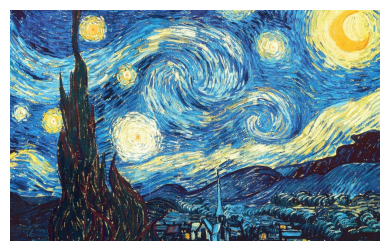

In [1]:
from PIL import Image

image_path = "./images/starry_night.jpg"
image = Image.open(image_path)

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.imshow(image)
plt.axis("off")
plt.show()

## opencv 라이브러리

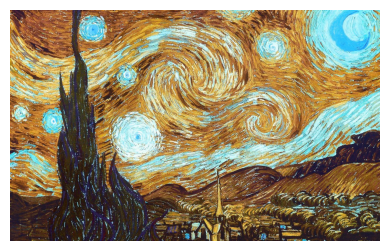

In [2]:
import cv2

image_path = "./images/starry_night.jpg"
image_cv2 = cv2.imread(image_path)

plt.figure(figsize=(5, 3))
plt.imshow(image_cv2)
plt.axis("off")
plt.show()

In [3]:
# image와 image_cv의 차이 파악하기
import numpy as np

print(f"pillow 라이브러리: {np.array(image)[0][0]}")  # R, G, B
print(f"opencv 라이브러리: {image_cv2[0][0]}")  # B, G, R

pillow 라이브러리: [  6  22 109]
opencv 라이브러리: [109  22   6]


# 2. 이미지 변환하기

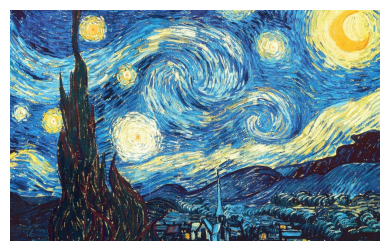

In [4]:
image_cv2_rgb = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 3))
plt.imshow(image_cv2_rgb)
plt.axis("off")
plt.show()

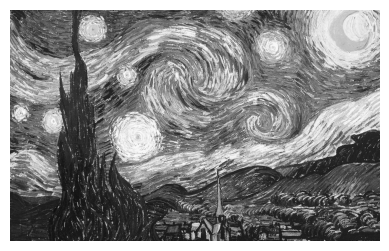

In [5]:
image_cv2_gray = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 3))
plt.imshow(image_cv2_gray, cmap="gray")
plt.axis("off")
plt.show()

# 3. 이미지 정보 파악하기

In [6]:
print(type(image_cv2))  # image_cv2는 넘파이 배열입니다.
print(image_cv2.shape)
print(image_cv2.ndim)
print(image_cv2.dtype)
print(image_cv2.size)

<class 'numpy.ndarray'>
(640, 1024, 3)
3
uint8
1966080


# 4. 이미지 저장하기 

In [7]:
save_path = "./images/starry_night_gray.jpg"

cv2.imwrite(save_path, image_cv2_gray)

True

# 5. 이미지 그리기

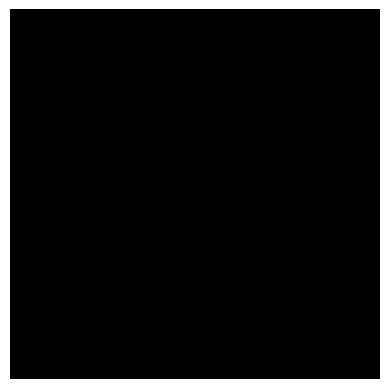

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 검은 도화지 만들기(0~255, 0 0 0 흰색, 255 255 255 검은색)
image = np.zeros((200, 200, 3), dtype=np.uint8)

plt.imshow(image)
plt.axis("off")
plt.show()

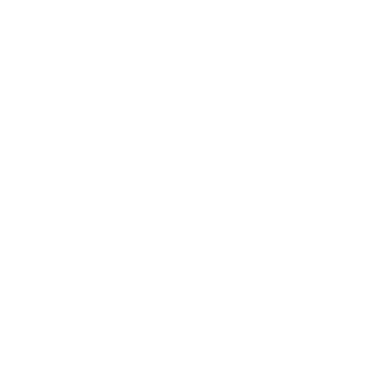

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 흰 도화지 만들기(0~255, 0 0 0 검은색, 255 255 255 흰색)
image = np.ones((200, 200, 3), dtype=np.uint8) * 255

plt.imshow(image)
plt.axis("off")
plt.show()

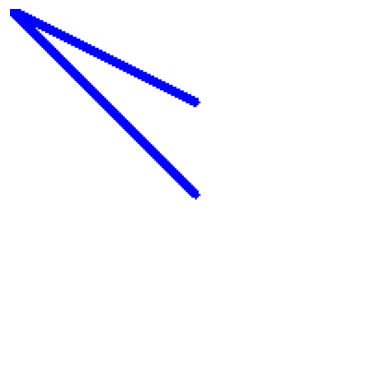

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 흰 도화지 만들기(0~255, 0 0 0 검은색, 255 255 255 흰색)
image = np.ones((200, 200, 3), dtype=np.uint8) * 255

# 선 그리기 (이미지 - 왼쪽위 - 오른쪽 아래 - 색상 - 두께 - (옵션: 선 스타일))
cv2.line(image, (0, 0), (100, 100), (0, 0, 255), 3, lineType=cv2.FILLED)
cv2.line(image, (0, 0), (100, 50), (0, 0, 255), 3, lineType=cv2.LINE_4)

plt.imshow(image)
plt.axis("off")
plt.show()

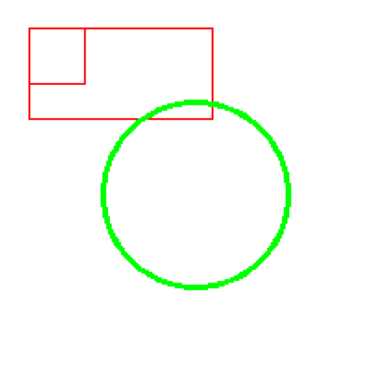

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 흰 도화지 만들기(0~255, 0 0 0 검은색, 255 255 255 흰색)
image = np.ones((200, 200, 3), dtype=np.uint8) * 255

# 사각형 그리기 I (이미지 - 왼쪽위 - 오른쪽 아래 - 색상 - 두께 - (옵션: 선 스타일))
cv2.rectangle(image, (10, 10), (40, 40), (255, 0, 0), 1)
# 사각형 그리기 II (이미지 - (x1, y1, w, h) - 색상 - 두께 - (옵션: 선 스타일))
cv2.rectangle(image, (10, 10, 100, 50), (255, 0, 0), 1)
# 원 그리기 (이미지 - 중심점 - 반지름 - 색상 - 두께 - (옵션))
cv2.circle(image, (100, 100), 50, (0, 255, 0), 2)

plt.imshow(image)
plt.axis("off")
plt.show()

# 6. 마스크 씌우기

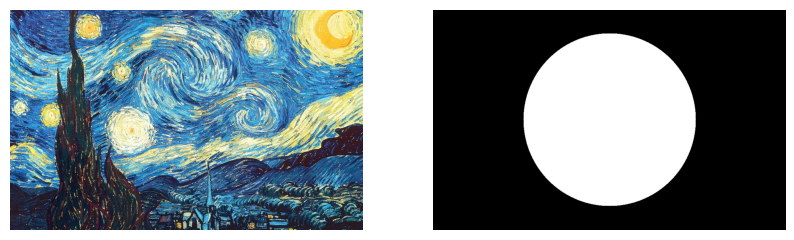

In [13]:
import cv2
import matplotlib.pyplot as plt

image_path = "./images/starry_night.jpg"
mask_path = "./images/circle.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(image)
ax[0].axis("off")
ax[1].imshow(mask)
ax[1].axis("off")

plt.show()

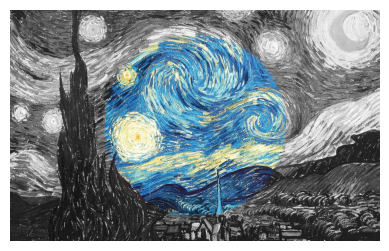

In [14]:
import cv2
import matplotlib.pyplot as plt

image_path = "./images/starry_night.jpg"
mask_path = "./images/circle.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
dst = cv2.imread("./images/starry_night_gray.jpg")

cv2.copyTo(image, mask, dst)

plt.figure(figsize=(5, 3))
plt.imshow(dst)
plt.axis("off")
plt.show()

# 7. 이미지 처리

## 1) 색상 추출

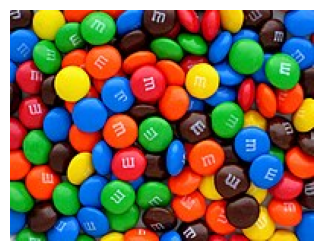

In [15]:
import cv2

image_path = "./images/chocolate.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 3))
plt.imshow(image)
plt.axis("off")
plt.show()

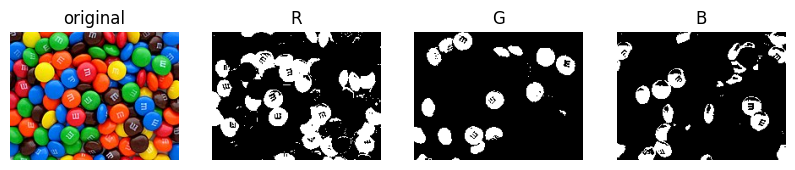

In [17]:
# 색상별로 마스크 만들기
mask_r = cv2.inRange(image, (128, 0, 0), (255, 128, 128))
mask_g = cv2.inRange(image, (0, 128, 0), (128, 255, 128))
mask_b = cv2.inRange(image, (0, 0, 128), (128, 128, 255))

fig, ax = plt.subplots(1, 4, figsize=(10, 4))
ax[0].imshow(image)
ax[0].set_title("original")
ax[0].axis("off")
ax[1].imshow(mask_r, cmap="gray")
ax[1].set_title("R")
ax[1].axis("off")
ax[2].imshow(mask_g, cmap="gray")
ax[2].set_title("G")
ax[2].axis("off")
ax[3].imshow(mask_b, cmap="gray")
ax[3].set_title("B")
ax[3].axis("off")

plt.show()

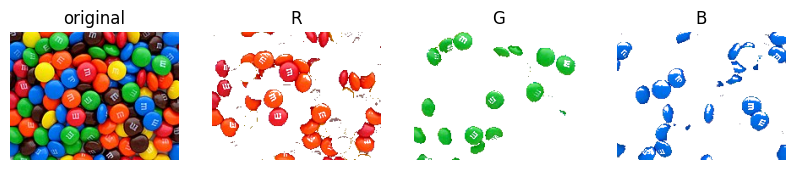

In [22]:
# copyTo(image, mask, dst) : original에서 mask를 뽑아서 흰 도화지에 붙인다.
white_dst = np.ones(image.shape, dtype=np.uint8) * 255
image_R = cv2.copyTo(image, mask_r, white_dst)

white_dst = np.ones(image.shape, dtype=np.uint8) * 255
image_G = cv2.copyTo(image, mask_g, white_dst)

white_dst = np.ones(image.shape, dtype=np.uint8) * 255
image_B = cv2.copyTo(image, mask_b, white_dst)

fig, ax = plt.subplots(1, 4, figsize=(10, 4))
ax[0].imshow(image)
ax[0].set_title("original")
ax[0].axis("off")
ax[1].imshow(image_R, cmap="gray")
ax[1].set_title("R")
ax[1].axis("off")
ax[2].imshow(image_G, cmap="gray")
ax[2].set_title("G")
ax[2].axis("off")
ax[3].imshow(image_B, cmap="gray")
ax[3].set_title("B")
ax[3].axis("off")

plt.show()

## 2) 가우시안 블러

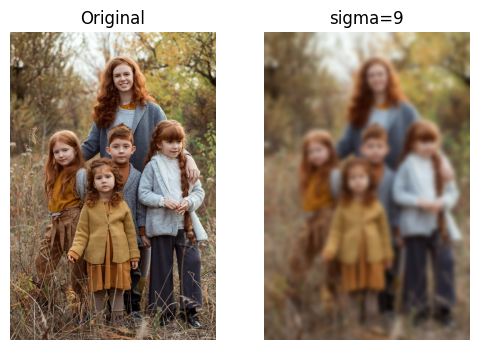

In [25]:
import cv2

image_path = "./images/family.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sigma = 9
image_blur = cv2.GaussianBlur(image, (0, 0), sigma)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(image)
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(image_blur)
ax[1].set_title(f"sigma={sigma}")
ax[1].axis("off")
plt.show()

## 3) 밝기/대비 조절

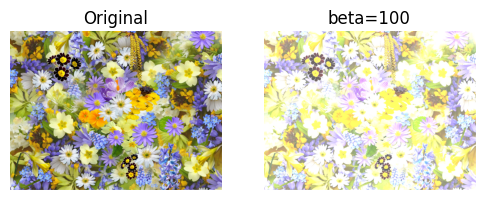

In [36]:
# 밝기 조절: 전체 색을 밝히는 것
import cv2

image_path = "./images/flowers.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# beta를 바꿔보세요
beta = 100
image_bright = cv2.convertScaleAbs(image, alpha=1, beta=beta)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(image)
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(image_bright)
ax[1].set_title(f"beta={beta}")
ax[1].axis("off")
plt.show()

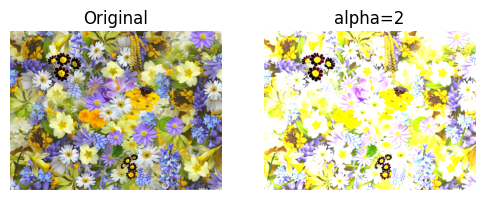

In [ ]:
#대비 조절: 밝은 색과 어두운 색의 차이를 크게 하는 것
import cv2

image_path = "./images/flowers.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# alpha를 바꿔보세요
alpha = 2
image_bright = cv2.convertScaleAbs(image, alpha=alpha, beta=1)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(image)
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(image_bright)
ax[1].set_title(f"alpha={alpha}")
ax[1].axis("off")
plt.show()